# SPHEREx Self-calibration Test

In [5]:
import glob
import os
import h5py
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 400 # User can set this outside the class if needed

from astropy.io import fits
from astropy.io.votable import parse_single_table
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.coordinates import SkyCoord
import astropy.units as u

import sys 
import gc 

import importlib
# sys.path.insert(0, '/home/thomasli/spherex/selfcal')
from SelfCal import EuclidUtility
from SelfCal import WCSHelper
from SelfCal import MakeMap
from SelfCal import MapHelper
importlib.reload(MapHelper)

import os
import h5py
from tqdm import tqdm
from multiprocessing import Pool 
from concurrent.futures import ProcessPoolExecutor, as_completed, ThreadPoolExecutor
import numpy as np

from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
import astropy.units as u
from astropy.table import Table

from reproject import reproject_interp
from reproject import reproject_exact
from reproject import reproject_adaptive

from scipy.sparse import coo_matrix
from scipy.sparse.linalg import lsqr
import sys 
import gc 
from functools import partial

from SelfCal.MapHelper import bit_to_bool, make_weight, find_outliers, map_pixels,compute_chunk_contrib, det_to_grid
from SelfCal.WCSHelper import load_from_fits, save_to_fits, find_optimal_frame
from SelfCal.SPHERExUtility import interpolate_array, make_chunk_map, make_chunk_mask, visualize_chunk_map


In [13]:
importlib.reload(MakeMap)

<module 'SelfCal.MakeMap' from '/home/thomasli/spherex/selfcal/SelfCal/MakeMap.py'>

In [9]:
detector = 1
exposure_list = glob.glob(f'/data1/SPHEREx/deep_north/*/*/*/*D{detector}*.fits')
print(f"Found {len(exposure_list)} exposures")


Found 2809 exposures


In [3]:
ref_wcs, ref_shape = find_optimal_frame(
                exposure_list=exposure_list,
                resolution_arcsec=3.1,
                padding_pixels=100,
                use_ext=[1])

Defining optimal celestial WCS...


Loading corner WCS: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 1831/1831 [00:46<00:00, 38.98it/s]


In [ ]:
WCSHelper.save_to_fits(ref_wcs, ref_shape, '/home/thomasli/spherex/selfcal/nep_det2_3p1arcsec/ref.fits')

Reference frame FITS saved to: /home/thomasli/spherex/selfcal/nep_det2_3p1arcsec/ref.fits


In [2]:
ref_wcs, ref_shape = load_from_fits('/data1/thomasli/selfcal/outputs/nep_det1_6p2arcsec/ref.fits')

Loading reference frame from: /data1/thomasli/selfcal/outputs/nep_det1_6p2arcsec/ref.fits


In [14]:
reproj_list = MakeMap.batch_reproject(
    # Can edit
    num_processes = 50,
    method = 'exact',  # interp: fastest, adaptive: conserves flux

    # Porbably don't want to edit
    exposure_list = exposure_list[:20],
    ref_wcs = ref_wcs, 
    ref_shape = ref_shape,
    output_dir = '/home/thomasli/spherex/selfcal/nep_det4_3p1arcsec', 
    padding_percentage = 0.05,
    oversample_factor= 2,
    sci_ext_list = [1], 
    dq_ext_list = [2],
    exp_idx_list = np.arange(0, len(exposure_list) ),
    det_idx_list = [0]*len(exposure_list),  # Assuming all exposures are for the same detector
    replace_existing = False
    )

Starting batch reprojection. Output will be saved to: /home/thomasli/spherex/selfcal/nep_det4_3p1arcsec


Reprojecting frames: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [02:39<00:00,  7.95s/it]

Batch reprojection completed. 20 frames successfully processed out of 20.


In [3]:
reproj_list = sorted(glob.glob('/data1/thomasli/selfcal/outputs/nep_det1_6p2arcsec/reprojected/*.h5'))

det_idx_list = []
exp_idx_list = []
for file in tqdm(reproj_list):
    file_name = os.path.basename(file)
    det_idx_list.append(int(file_name[file_name.find('det_')+4:file_name.find('det_')+6]))
    exp_idx_list.append(int(file_name[file_name.find('exp_')+4:file_name.find('exp_')+8]))

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3458/3458 [00:00<00:00, 1205844.96it/s]


In [4]:
reproj_sample = MakeMap.load_reproj_file(reproj_list[0], fields=['sub_data','grid_bitmask', 'grid_mapping'])

In [27]:
from skimage import measure
from scipy.interpolate import make_smoothing_spline


In [31]:
def load_calibration(band, calibration_dir='/home/thomasli/spherex/spherex_calibration'):
    BC_files = glob.glob(os.path.join(calibration_dir, f'*BC_Band{band}.fits'))
    BW_files = glob.glob(os.path.join(calibration_dir, f'*BW_Band{band}.fits'))
    if len(BC_files) != 1 or len(BW_files) != 1:
        raise ValueError(f"Expected one BC and one BW file for band {band}, found {len(BC_files)} BC files and {len(BW_files)} BW files.")
    BC_map = fits.getdata(BC_files[0])
    BW_map = fits.getdata(BW_files[0])
    return BC_map, BW_map

def make_chunk_map(band, BC_map, interp_factor=5,
                   channel_file='/home/thomasli/spherex/spherex_nep_catalogues/spherex_channels.csv'):
    tbl = Table.read(channel_file)
    sub_tbl = tbl[tbl['band'] == band]
    channel_edges = np.hstack([sub_tbl['lmin'].data, sub_tbl['lmax'].data[-1:]])
    fine_edges = interpolate_array(channel_edges, interp_factor=interp_factor)
    channel_idx = np.searchsorted(fine_edges, BC_map, side='right')

    mask_smooth = np.zeros_like(channel_idx)

    for i in tqdm(np.unique(channel_idx)[:]):
        mask = channel_idx >= i
        contours = measure.find_contours(mask, level=0.1, positive_orientation='low')
        if len(contours) == 0:
            continue
        contour = []
        for c in contours:
            if len(c) > 500:  # Filter out small contours
                contour.append(c)
        contour = np.concatenate(contour)
        ys, xs = contour[:, 0], contour[:, 1]

        # sort
        sorted_indices = np.argsort(xs)
        xs = xs[sorted_indices]
        ys = ys[sorted_indices]
        # remove duplicates
        unique_indices = np.unique(xs, return_index=True)[1]
        xs = xs[unique_indices]
        ys = ys[unique_indices]

        spl = make_smoothing_spline(xs, ys, lam=1e7)
        x_idx = np.arange(mask_smooth.shape[1])
        y_lim = spl(x_idx)
        y_lim = np.clip(y_lim, 0, mask_smooth.shape[0]-1)

        for x, y in zip(x_idx, y_lim):
            mask_smooth[:int(y+0.5), int(x)] = i

    return mask_smooth

det_BC, det_BW = load_calibration(band=1)

chunk_map = make_chunk_map(1, det_BC, interp_factor=1,
                   channel_file='/home/thomasli/spherex/spherex_nep_catalogues/spherex_channels.csv')

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:01<00:00, 16.32it/s]


In [19]:
grid_BC, grid_BW = det_to_grid(reproj_sample['grid_mapping'], np.stack([det_BC, det_BW]))

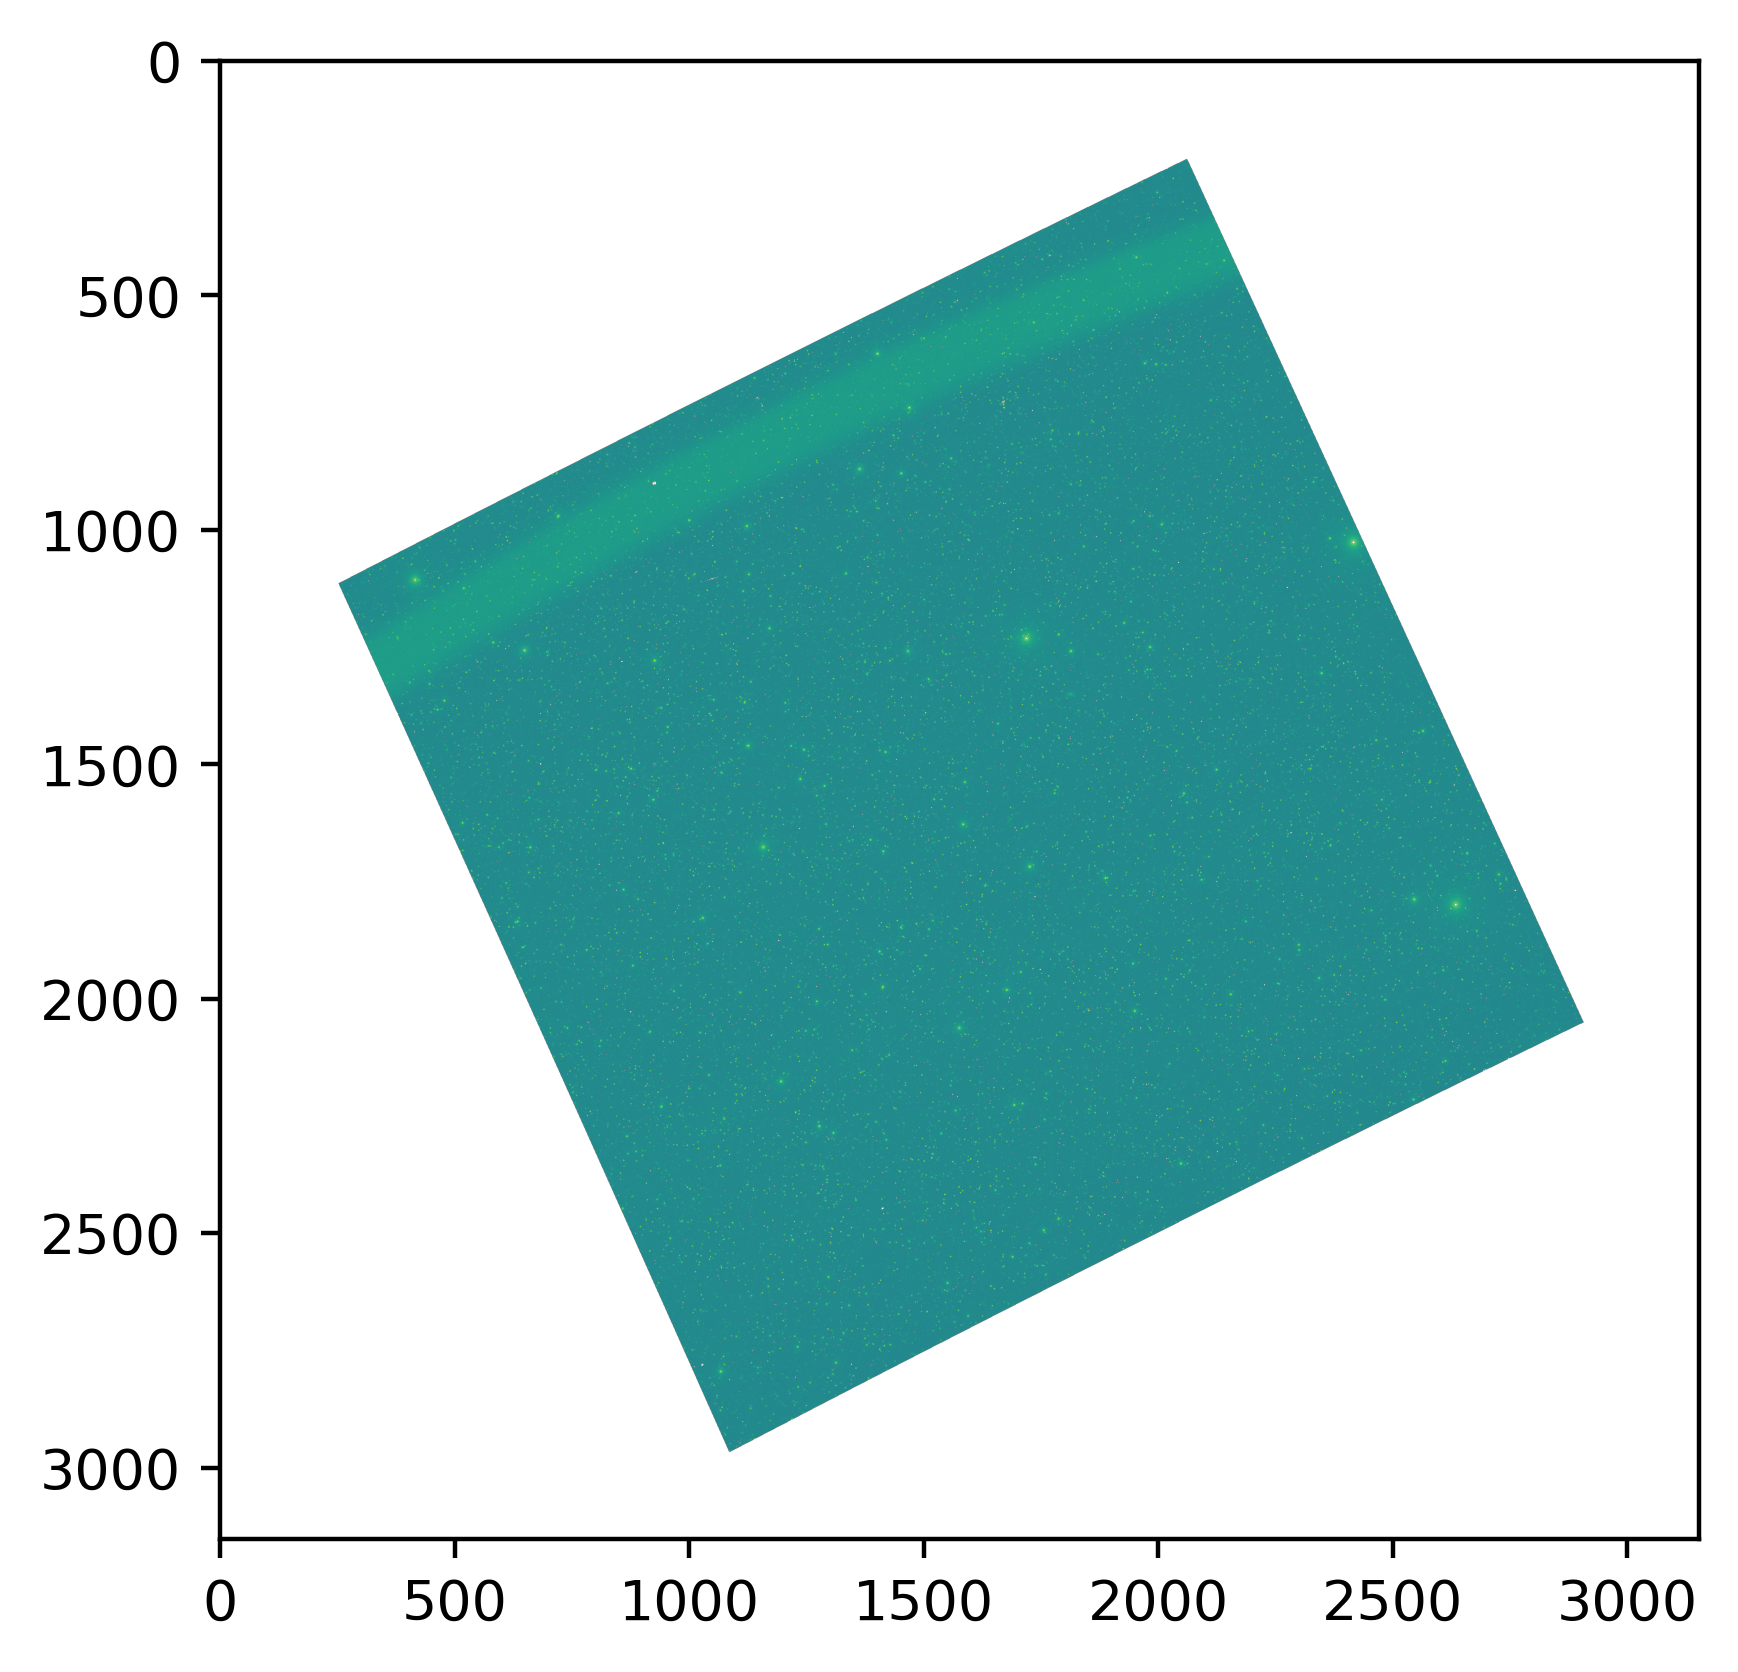

In [22]:
plt.imshow(reproj_sample['sub_data'], norm=LogNorm())

In [23]:
from SelfCal.MapHelper import parse_grid_mapping

In [18]:
# plt.imshow(reproj_sample['sub_data'], norm=LogNorm(vmin=0.05, vmax=0.3))

In [46]:
for f in tqdm(reproj_list):
    result = MakeMap.load_reproj_file(f, fields=['sub_data',])
    if result['_is_missing_']:
        os.remove(f)
        print(f"Removed {f} due to missing data")

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1805/1805 [06:45<00:00,  4.46it/s]


In [39]:
chunk_map = make_chunk_map(1, interp_factor=10)
chunk_valid_mask = make_chunk_mask([16,], interp_factor=10)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 172/172 [00:11<00:00, 15.43it/s]


In [47]:
det_valid_mask = chunk_valid_mask[chunk_map]

In [118]:
importlib.reload(MakeMap)
importlib.reload(MapHelper)

<module 'SelfCal.MapHelper' from '/home/thomasli/spherex/selfcal/SelfCal/MapHelper.py'>

In [109]:
np.nonzero(chunk_valid_mask)

(array([151, 152, 153, 154, 155, 156, 157, 158, 159, 160]),)

In [110]:
dummy_offset = np.zeros((2, 172))
dummy_offset[:,151:161] = np.arange(10)

In [111]:
mosaic, weight = MakeMap.compute_mean_map(
    ref_shape=ref_shape,
    reproj_file_list=reproj_list[0:2],
    offset=dummy_offset,
    det_idx_list=det_idx_list,
    exp_idx_list=exp_idx_list,
    apply_weight=True,
    apply_mask=False,
    chunk_map=chunk_map,
    max_workers=20,
    det_valid_mask=det_valid_mask,
)

Computing mean map:   0%|                                                                                                                                                         | 0/2 [00:00<?, ?it/s]

hi
hi


Computing mean map: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:08<00:00,  4.23s/it]


In [113]:
# plt.imshow(mosaic, norm=LogNorm(vmin=0.05, vmax=0.2))

In [ ]:
A, b = MakeMap.setup_lsqr(reproj_list[:], ref_shape, exp_idx_list[:], det_idx_list[:],
               apply_mask=True, apply_weight=False, chunk_map=chunk_map, det_valid_mask=det_valid_mask,
               max_workers=40, outlier_thresh=100)

Building A, b matrix: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3458/3458 [11:41<00:00,  4.93it/s]


In [27]:
O, S = MakeMap.apply_lsqr(A, b, ref_shape, exp_idx_list, det_idx_list, x0=None, 
                atol=1e-06, btol=1e-06, damp=1e-1, iter_lim=500) 

Solving least squares for 80985710 unknowns with 417787125 equations.
 
LSQR            Least-squares solution of  Ax = b
The matrix A has 417787125 rows and 80985710 columns
damp = 1.00000000000000e-01   calc_var =        0
atol = 1.00e-06                 conlim = 1.00e+08
btol = 1.00e-06               iter_lim =      500
 
   Itn      x[0]       r1norm     r2norm   Compatible    LS      Norm A   Cond A
     0  0.00000e+00   1.051e+04  1.051e+04    1.0e+00  1.0e-02
     1  0.00000e+00   1.445e+03  1.445e+03    1.4e-01  7.8e-01   1.1e+02  1.0e+00
     2  0.00000e+00   7.889e+02  7.889e+02    7.5e-02  2.1e-01   1.5e+02  2.0e+00
     3  0.00000e+00   7.474e+02  7.475e+02    7.1e-02  4.2e-02   1.8e+02  3.1e+00
     4  0.00000e+00   7.451e+02  7.452e+02    7.1e-02  1.1e-02   2.1e+02  4.1e+00
     5  0.00000e+00   7.447e+02  7.448e+02    7.1e-02  1.1e-02   2.2e+02  5.5e+00
     6  0.00000e+00   7.430e+02  7.431e+02    7.1e-02  2.7e-02   2.4e+02  1.1e+01
     7  0.00000e+00   7.310e+02  7.31

In [116]:
importlib.reload(MakeMap)

<module 'MakeMap' from '/home/thomasli/spherex/selfcal/MakeMap.py'>

In [ ]:
# plt.imshow(S, norm=LogNorm())

In [ ]:
O[:,chunk_valid_mask==1].ravel()

array([0.40907436, 0.54753682, 0.70883526, ..., 0.54343221, 0.54710393,
       0.55133433], shape=(18000,))

: 

In [36]:
O[:,chunk_valid_mask==1]

array([[0.28680885, 0.38878522, 0.50360582, ..., 0.63564666, 0.63900152,
        0.63946421],
       [0.27330622, 0.35955439, 0.45972508, ..., 0.56799061, 0.57176592,
        0.57365043],
       [0.24082425, 0.31062251, 0.39053559, ..., 0.47732807, 0.48082449,
        0.48121218],
       ...,
       [0.22529767, 0.28588783, 0.35810214, ..., 0.43631015, 0.43872107,
        0.43977058],
       [0.28280894, 0.39263449, 0.51719764, ..., 0.66047288, 0.66580426,
        0.66919616],
       [0.42127706, 0.61855442, 0.84732302, ..., 1.11570789, 1.14252719,
        1.1775743 ]], shape=(3458, 10))

In [30]:
mean_map, weight = MakeMap.compute_mean_map(
    ref_shape=ref_shape,
    reproj_file_list=reproj_list[:],
    offset=O-np.mean(O[:,chunk_valid_mask==1]),
    det_idx_list=det_idx_list,
    exp_idx_list=exp_idx_list,
    apply_weight=False,
    apply_mask=True,
    chunk_map=chunk_map,
    max_workers=40,
    det_valid_mask = det_valid_mask,
    ignore_list=[21]
)

Computing mean map: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [08:39<00:00, 12.98s/it]


In [2]:
# plt.imshow(mean_map, norm=LogNorm(vmin=0.25, vmax=1.5))

In [32]:
crop = O[:,chunk_valid_mask==1]

In [1]:
# _ = plt.plot(np.arange(crop.shape[1]), crop[0:100].T)

In [17]:
mos = fits.open('/home/thomasli/spherex/selfcal/outputs/nep_det1_6p2arcsec/mosaic/nep_6p2arcsec_det1_ch16.fits')[0].data

In [117]:
std_map, weight = MakeMap.compute_std_map(
    mean_map, 
    ref_shape,
    reproj_list,
    exp_offset=O-np.mean(O, axis=0),
    det_offset=[D-np.mean(D[chunk_valid_mask==1], axis=0)],
    det_idx_list=det_idx_list,
    exp_idx_list=exp_idx_list,
    apply_weight=True,
    apply_mask=False,
    chunk_map=chunk_map,
    max_workers=40,
    chunk_valid_mask = chunk_valid_mask,
)

Computing std map: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [03:28<00:00,  5.21s/it]


In [134]:
sc_mean, weight = MakeMap.compute_sc_mean(
    mean_map=mean_map,
    std_map=std_map,
    sigma=1.0,
    ref_shape=ref_shape,
    reproj_file_list=reproj_list[:],
    exp_offset=O-np.mean(O, axis=0),
    det_offset=[D-np.mean(D[chunk_valid_mask==1], axis=0)],
    det_idx_list=det_idx_list,
    exp_idx_list=exp_idx_list,
    apply_weight=True,
    apply_mask=False,
    chunk_map=chunk_map,
    max_workers=40,
    chunk_valid_mask = chunk_valid_mask,
)

Sigma-clipped coadd: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [03:34<00:00,  5.35s/it]


In [139]:
# plt.imshow(mosaic, norm=LogNorm(vmin=0.05, vmax=0.5))

In [140]:
# plt.imshow(sc_mean, norm=LogNorm(vmin=0.05, vmax=0.5))

In [141]:
# plt.imshow(sc_mean-mean_map, vmin=-0.001, vmax=0.001)

In [129]:
def plot_map(map, wcs):
    high, low = np.nanpercentile(map[map>0], [95, 10])
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection=wcs)
    im = ax.imshow(map, norm=LogNorm(vmin=low, vmax=high), origin='lower')

    # Explicitly set axis labels
    ax.coords['ra'].set_axislabel('RA')
    ax.coords['ra'].set_axislabel_position('b')  # Ensure RA label is only at the bottom
    ax.coords['ra'].set_ticks_position('b')  # Set RA ticks only at the bottom
    ax.coords['ra'].set_ticklabel_position('b')  # Set RA tick labels only at the bottom
    ax.coords['dec'].set_axislabel('DEC')

    # Add grid overlay
    ax.grid(color='black', linestyle='--', alpha=0.5)

    # Rescale the colorbar to match the height of the plot
    cbar = plt.colorbar(im, ax=ax, orientation='vertical', fraction=0.040, pad=0.04)
    cbar.set_label('MJy/sr')

In [60]:
def save_mosaic(mosaic, ref_wcs, ref_shape, file_path='.fits', O=[], D=[], S=[], overwrite=False):
    mosaic_hdu = fits.PrimaryHDU(data=mosaic, header=ref_wcs.to_header())
    mosaic_hdu.header['NAXIS1'] = ref_shape[1]
    mosaic_hdu.header['NAXIS2'] = ref_shape[0]
    mosaic_hdu.header['NAXIS'] = 2
    mosaic_hdu.header['BUNIT'] = 'MJy/sr'
    mosaic_hdu.header['EXTNAME'] = 'MOSAIC'

    O_hdu = fits.ImageHDU(data=O, name='EXP_OFFSET')
    O_hdu.header['BUNIT'] = 'MJy/sr'
    O_hdu.header['EXTNAME'] = 'EXP_OFFSET'

    D_hdu = fits.ImageHDU(data=D, name='DET_OFFSET')
    D_hdu.header['BUNIT'] = 'MJy/sr'
    D_hdu.header['EXTNAME'] = 'DET_OFFSET'

    S_hdu = fits.ImageHDU(data=S, name='SKY')
    S_hdu.header['BUNIT'] = 'MJy/sr'
    S_hdu.header['EXTNAME'] = 'SKY'

    # repro

    hdul = fits.HDUList([mosaic_hdu, O_hdu, D_hdu, S_hdu])
    hdul.writeto(file_path, overwrite=overwrite)
    return hdul

In [570]:
hdu = save_mosaic(mosaic, ref_wcs, ref_shape, '/home/thomasli/spherex/selfcal/outputs/nep_det2_ch3-4_6p2arcsec.fits', O=O, D=D)

In [61]:
from IPython.display import clear_output

In [ ]:
channels_list = [[1,2]]
for chs in channels_list:
    if os.path.exists(f'/home/thomasli/spherex/selfcal/outputs/nep_det3_ch{chs[0]}_6p2arcsec.fits'):
        continue
    print(f"Processing channels {chs[0]}")
    
    interp_factor = 5
    chunk_map = make_chunk_map(2, interp_factor=interp_factor)

    chunk_valid_mask = np.zeros(17*interp_factor + 2)  # 17 channels
    chunk_valid_mask[np.hstack(((np.array(chs)-1)*interp_factor)[:, None] + np.arange(interp_factor)) + 1] = 1

    A, b = MakeMap.setup_lsqr(reproj_list[:], ref_shape, exp_idx_list[:], det_idx_list[:],
               apply_mask=True, apply_weight=True, chunk_map=chunk_map, chunk_valid_mask=chunk_valid_mask,
               max_workers=20)
    
    O, S, D = MakeMap.apply_lsqr(A, b, ref_shape, exp_idx_list, det_idx_list, x0=None, 
                atol=1e-06, btol=1e-06, damp=1e-2, iter_lim=300) 

    mosaic, weight = MakeMap.compute_mean_map(
        ref_shape=ref_shape,
        reproj_file_list=reproj_list[:],
        exp_offset=O-np.mean(O, axis=0),
        det_offset=[D-np.mean(D[chunk_valid_mask==1], axis=0)],
        det_idx_list=det_idx_list,
        exp_idx_list=exp_idx_list,
        apply_weight=True,
        apply_mask=False,
        chunk_map=chunk_map,
        max_workers=20,
        chunk_valid_mask = chunk_valid_mask,
    )

    hdu = save_mosaic(mosaic, ref_wcs, ref_shape, f'/home/thomasli/spherex/selfcal/outputs/nep_det4_ch{chs[0]}_6p2arcsec.fits', 
                      O=O, D=D, overwrite=True)

    clear_output(wait=True)


Processing channels 2


Building A, b matrix: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1732/1732 [06:54<00:00,  4.18it/s]


Solving least squares for 89679979 unknowns with 347009004 equations.
 
LSQR            Least-squares solution of  Ax = b
The matrix A has 347009004 rows and 89679979 columns
damp = 1.00000000000000e-02   calc_var =        0
atol = 1.00e-06                 conlim = 1.00e+08
btol = 1.00e-06               iter_lim =      300
 
   Itn      x[0]       r1norm     r2norm   Compatible    LS      Norm A   Cond A
     0  0.00000e+00   3.324e+04  3.324e+04    1.0e+00  1.6e-01
     1  0.00000e+00   3.943e+03  3.943e+03    1.2e-01  6.8e-01   5.5e+03  1.0e+00
     2  0.00000e+00   2.799e+03  2.799e+03    8.4e-02  1.2e-01   7.6e+03  2.0e+00
     3  0.00000e+00   2.745e+03  2.745e+03    8.3e-02  4.4e-02   9.0e+03  3.1e+00
     4  0.00000e+00   2.732e+03  2.732e+03    8.2e-02  2.4e-02   1.0e+04  4.3e+00
     5  0.00000e+00   2.728e+03  2.728e+03    8.2e-02  1.1e-02   1.1e+04  5.8e+00
     6  0.00000e+00   2.726e+03  2.726e+03    8.2e-02  3.8e-03   1.2e+04  7.1e+00
     7  0.00000e+00   2.726e+03  2.72

Computing mean map [1600/1732]: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 132/132 [01:53<00:00,  1.17it/s]


In [168]:
# fig = plt.figure(figsize=(10, 10))
# ax = fig.add_subplot(111, projection=ref_wcs)
# im = ax.imshow(mosaic, norm=LogNorm(vmin=0.001, vmax=0.3), origin='lower')

# # Explicitly set axis labels
# ax.coords['ra'].set_axislabel('RA')
# ax.coords['ra'].set_axislabel_position('b')  # Ensure RA label is only at the bottom
# ax.coords['ra'].set_ticks_position('b')  # Set RA ticks only at the bottom
# ax.coords['ra'].set_ticklabel_position('b')  # Set RA tick labels only at the bottom
# ax.coords['dec'].set_axislabel('DEC')

# # Add grid overlay
# ax.grid(color='black', linestyle='--', alpha=0.5)

# # Rescale the colorbar to match the height of the plot
# cbar = plt.colorbar(im, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
# cbar.set_label('MJy/sr')

# # Add title
# ax.set_title("Detector 2 (1.17-2.23um)", pad=20)
# plt.savefig('/home/thomasli/spherex/selfcal/figures/det2_mosaic.png', dpi=300, bbox_inches='tight')

In [1]:
spherex_channels_tbl = Table.read('/home/thomasli/spherex/spherex_nep_catalogues/spherex_channels.csv')
sub_tbl = spherex_channels_tbl[spherex_channels_tbl['band'] == 2]
lmin  = interpolate_array(sub_tbl['lmin'].data, interp_factor=5)
lmax  = interpolate_array(sub_tbl['lmax'].data, interp_factor=5)


NameError: name 'Table' is not defined

In [166]:
# plt.plot(((lmax+lmin)/2)[valid_D], D[1:-1][valid_D]-np.mean(D[1:-1][valid_D]), 'o', label='Detector 2')
# plt.xlabel('Wavelength [um]')
# plt.ylabel('Detector Offset [MJy/sr]')

In [161]:
coverage_map = MakeMap.compute_coverage_map(ref_shape, reproj_list[:], 
                                            exp_offset=O-np.mean(O), det_offset=[D-np.mean(D[np.nonzero(D)])], 
                                            exp_idx_list=exp_idx_list, det_idx_list=det_idx_list,
                                            chunk_map=chunk_map, chunk_valid_mask=chunk_valid_mask, max_workers=40)

Computing mean map [1600/1837]: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 237/237 [01:59<00:00,  1.99it/s]


In [167]:
# fig = plt.figure(figsize=(10, 10))
# ax = fig.add_subplot(111, projection=ref_wcs)
# im = plt.imshow(coverage_map, origin='lower', cmap='bwr', vmin=-0.4, vmax=0.4)

# # Explicitly set axis labels
# ax.coords['ra'].set_axislabel('RA')
# ax.coords['ra'].set_axislabel_position('b')  # Ensure RA label is only at the bottom
# ax.coords['ra'].set_ticks_position('b')  # Set RA ticks only at the bottom
# ax.coords['ra'].set_ticklabel_position('b')  # Set RA tick labels only at the bottom
# ax.coords['dec'].set_axislabel('DEC')

# # Add grid overlay
# ax.grid(color='black', linestyle='--', alpha=0.5)

# # Rescale the colorbar to match the height of the plot
# cbar = plt.colorbar(im, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
# cbar.set_label('MJy/sr')

# # Add title
# ax.set_title("Detector 2 (1.17-2.23um) Total Offset", pad=20)
# plt.savefig('/home/thomasli/spherex/selfcal/figures/det2_O+D.png', dpi=300, bbox_inches='tight')

In [ ]:
np.mean(D[np.nonzero(D)]), np.mean(D)

(np.float64(0.154219362026109), np.float64(0.02229677523269046))

In [ ]:
import MapHelper

In [176]:
reproj_sample = MakeMap.load_reproj_file(reproj_list[0], fields=['sub_data','grid_bitmask', 'grid_mapping'])

In [175]:
chunk_map = make_chunk_map(2, 10)

chunk_valid_mask = np.zeros(17*10 + 2)
chunk_valid_mask[np.hstack(((np.array([3])-1)*10)[:, None] + np.arange(10)) + 1] = 1

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 172/172 [00:11<00:00, 15.60it/s]


In [177]:
grid_mapping = reproj_sample['grid_mapping']
oversample_factor = 2

In [ ]:
contrib = MapHelper.compute_chunk_contrib(grid_mapping, chunk_map, oversample_factor)

In [182]:
file = reproj_list[0]
exp_offset = None
det_offset = None  # [100]+[0]*17
exp_idx = 0
det_idx = 0
apply_weight = True
apply_mask = True
chunk_map = chunk_map
chunk_valid_mask = chunk_valid_mask

In [219]:
chunk_valid_mask = np.zeros(17*10 + 2)
chunk_valid_mask[2:20:2] = 1

In [220]:
coords, data, weight, chunk_contrib = MakeMap._prep_subframe(file, exp_offset, det_offset, exp_idx, det_idx, 
            apply_weight, apply_mask, chunk_map, chunk_valid_mask)

In [228]:
np.sqrt(9859600)

np.float64(3140.0)

In [313]:
# plt.imshow(chunk_contrib.tocsc()[3].reshape(3140, 3140).toarray()+chunk_contrib.tocsc()[2].reshape(3140, 3140).toarray())